In [1]:
!pip install openai

In [2]:
from google.colab import userdata
from openai import OpenAI

client = OpenAI(
    api_key=userdata.get('OPENAI_API_KEY'),
    base_url="https://openrouter.ai/api/v1"
)

In [3]:
def gerar_embedding(texto):
    response = client.embeddings.create(
        model="nvidia/nemotron-3-embed-1b:free",
        input=texto,
        encoding_format="float"
    )
    return response.data[0].embedding, response.usage

In [4]:
embedding, uso = gerar_embedding("The quick brown fox jumps over the lazy dog")

print(f"Tamanho do vetor: {len(embedding)}")
print(f"Tokens gastos: {uso.total_tokens}")
print(f"\nPrimeiros 10 valores do vetor:")
print(embedding[:10])

Tamanho do vetor: 2048
Tokens gastos: 11

Primeiros 10 valores do vetor:
[0.09515459, -0.0010948398, -0.006354056, -0.029411761, -0.021192072, 0.040806904, -0.020835515, 0.033925354, -0.0038780821, -0.011751701]


In [5]:
def gerar_embeddings_em_lote(lista_textos):
    """
    Gera embeddings para uma lista de textos em uma única chamada à API.

    Parâmetros:
        lista_textos (list[str]): lista de palavras/textos a serem vetorizados.

    Retorna:
        embeddings (list[list[float]]): lista de vetores, na mesma ordem de entrada.
        total_tokens (int): total de tokens consumidos na chamada.
    """
    response = client.embeddings.create(
        model="nvidia/nemotron-3-embed-1b:free",
        input=lista_textos,
        encoding_format="float"
    )
    embeddings = [item.embedding for item in response.data]
    return embeddings, response.usage.total_tokens

In [6]:
!pip install scikit-learn matplotlib

In [7]:
palavras = ["gato", "felino", "cachorro", "carro", "caminhão", "moto", "banana", "maçã", "goiaba"]

embeddings_lista = []
for palavra in palavras:
    emb, _ = gerar_embedding(palavra)
    embeddings_lista.append(emb)
    print(f"✅ Embedding gerado para: {palavra}")

✅ Embedding gerado para: gato
✅ Embedding gerado para: felino
✅ Embedding gerado para: cachorro
✅ Embedding gerado para: carro
✅ Embedding gerado para: caminhão
✅ Embedding gerado para: moto
✅ Embedding gerado para: banana
✅ Embedding gerado para: maçã
✅ Embedding gerado para: goiaba


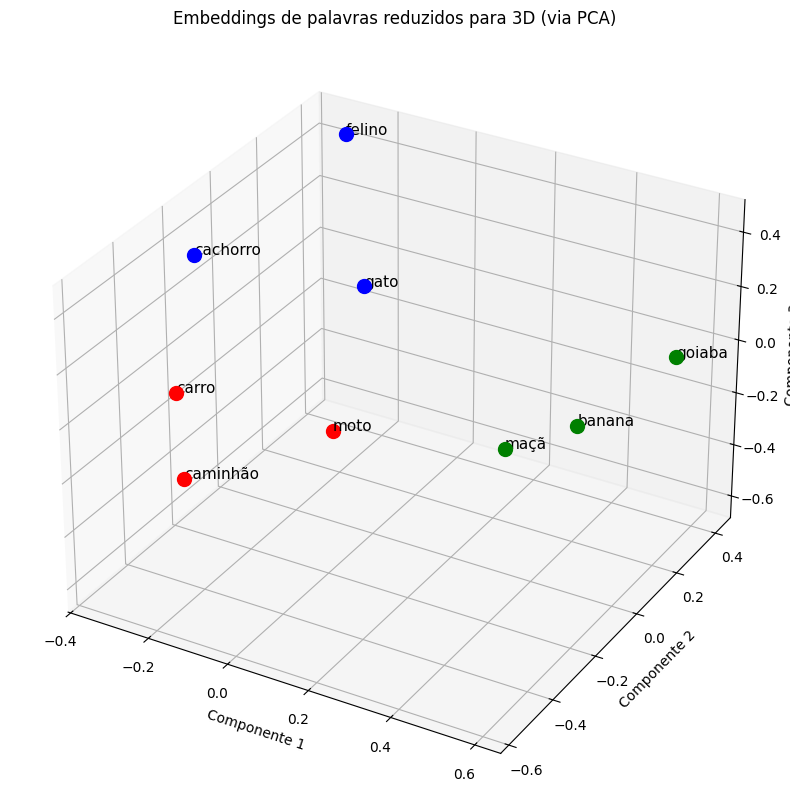

In [8]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=3)
coords_3d = pca.fit_transform(np.array(embeddings_lista))

cores = ['blue', 'blue', 'blue', 'red', 'red', 'red', 'green', 'green', 'green']

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

for i, palavra in enumerate(palavras):
    x, y, z = coords_3d[i]
    ax.scatter(x, y, z, c=cores[i], s=100)
    ax.text(x, y, z, palavra, fontsize=11)

ax.set_title("Embeddings de palavras reduzidos para 3D (via PCA)")
ax.set_xlabel("Componente 1")
ax.set_ylabel("Componente 2")
ax.set_zlabel("Componente 3")
plt.show()

In [9]:
import numpy as np

def distancia_euclidiana(vec1: np.ndarray, vec2: np.ndarray) -> float:
    """Calcula a Distância Euclidiana (norma L2 da diferença) entre dois vetores."""
    return float(np.linalg.norm(vec1 - vec2))

def similaridade_cosseno(vec1: np.ndarray, vec2: np.ndarray) -> float:
    """Calcula a Similaridade de Cosseno entre dois vetores."""
    norm_v1 = np.linalg.norm(vec1)
    norm_v2 = np.linalg.norm(vec2)
    if norm_v1 == 0 or norm_v2 == 0:
        return 0.0
    return float(np.dot(vec1, vec2) / (norm_v1 * norm_v2))

def distancia_cosseno(vec1: np.ndarray, vec2: np.ndarray) -> float:
    """Calcula a Distância de Cosseno (1 - Similaridade de Cosseno)."""
    return float(1.0 - similaridade_cosseno(vec1, vec2))

In [10]:
embedding_a = np.array([1, 0, 0])
embedding_b = np.array([0, 1, 0])
embedding_c = np.array([1, 0, 0])

pares = [
    ("a vs b", embedding_a, embedding_b),
    ("a vs c", embedding_a, embedding_c),
    ("b vs c", embedding_b, embedding_c),
]

for nome, v1, v2 in pares:
    print(f"{nome} -> euclidiana: {distancia_euclidiana(v1, v2):.4f} | "
          f"cosseno: {distancia_cosseno(v1, v2):.4f}")

a vs b -> euclidiana: 1.4142 | cosseno: 1.0000
a vs c -> euclidiana: 0.0000 | cosseno: 0.0000
b vs c -> euclidiana: 1.4142 | cosseno: 1.0000


In [11]:
palavras = ["gato", "felino", "cachorro", "carro", "caminhão", "moto", "banana", "maçã", "goiaba"]
embeddings_palavras, _ = gerar_embeddings_em_lote(palavras)
embeddings_palavras = [np.array(e) for e in embeddings_palavras]

# exemplo: comparar "gato" com todas as outras
idx_gato = palavras.index("gato")
vec_gato = embeddings_palavras[idx_gato]

for i, palavra in enumerate(palavras):
    if palavra == "gato":
        continue
    v = embeddings_palavras[i]
    print(f"gato vs {palavra:10s} -> euclidiana: {distancia_euclidiana(vec_gato, v):.4f} | "
          f"cosseno: {distancia_cosseno(vec_gato, v):.4f}")

gato vs felino     -> euclidiana: 1.1179 | cosseno: 0.6248
gato vs cachorro   -> euclidiana: 1.0931 | cosseno: 0.5974
gato vs carro      -> euclidiana: 1.1397 | cosseno: 0.6495
gato vs caminhão   -> euclidiana: 1.2189 | cosseno: 0.7428
gato vs moto       -> euclidiana: 1.0782 | cosseno: 0.5813
gato vs banana     -> euclidiana: 1.2584 | cosseno: 0.7918
gato vs maçã       -> euclidiana: 1.2614 | cosseno: 0.7955
gato vs goiaba     -> euclidiana: 1.2193 | cosseno: 0.7433


In [12]:
def get_embedding(texto):
    """Wrapper que retorna só o vetor de embedding (sem o objeto de uso)."""
    embedding, _ = gerar_embedding(texto)
    return embedding

In [13]:
import numpy as np
import pandas as pd

frase_ancora = "O cachorro correu no parque e brincou com a bola."

frases_comparacao = [
    ("Similar (mesmo sentido, palavras diferentes)", "Um cão estava correndo no jardim e brincando com seu brinquedo."),
    ("Relacionado (mesmo contexto de animais)", "O gato dormiu na almofada da sala durante toda a tarde."),
    ("Diferente (outro domínio - economia)", "A taxa de juros do banco central subiu dois pontos percentuais."),
    ("Oposto/Negação", "Nenhum animal esteve no parque e o cão permaneceu preso em casa.")
]

# 1. Gerar o embedding da âncora
vec_ancora = np.array(get_embedding(frase_ancora), dtype=np.float32)

# 2. Gerar os embeddings das comparações (desempacotando rótulo e frase)
vecs_comp = []
for rotulo, frase in frases_comparacao:
    vec = get_embedding(frase)
    vecs_comp.append(np.array(vec, dtype=np.float32))

# 3. Montar os resultados
resultados = []
for (rotulo, frase), vec in zip(frases_comparacao, vecs_comp):
    resultados.append({
        "Texto": rotulo,
        "Dist. Euclidiana": round(distancia_euclidiana(vec_ancora, vec), 4),
        "Similaridade Cosseno": round(similaridade_cosseno(vec_ancora, vec), 4),
        "Distância Cosseno": round(distancia_cosseno(vec_ancora, vec), 4)
    })

df_resultados = pd.DataFrame(resultados)
df_resultados

,Texto,Dist. Euclidiana,Similaridade Cosseno,Distância Cosseno
0,"Similar (mesmo sentido, palavras diferentes)",0.8465,0.6417,0.3583
1,Relacionado (mesmo contexto de animais),1.2289,0.2449,0.7551
2,Diferente (outro domínio - economia),1.3641,0.0697,0.9303
3,Oposto/Negação,0.9696,0.5299,0.4701
